In [ ]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt

from leakage.uncertainties import band_limited_noise
from leakage.conversions import dop2vel, angular_difference, dir_from_u_v, magnitude_from_u_v, convert_to_0_360
from sca_module.dopsca_setup import DopSCAConfig
from sca_module.simulate_L1 import compute_lpf_cube
from sca_module.simulate_L2 import GMF_SWB

func_rmse = lambda x, rounding=3:  np.round(np.sqrt(np.nanmean(x**2)), rounding)

plt.rcParams.update({'font.size': 10, 'font.weight' : 'bold'})

## 0 - Load DopSCA parameters

In [ ]:
sca = DopSCAConfig()
sca.Lambda = sca.get_wavelength()
sca.grid_spacing_target = sca.get_grid_spacing_target(magic_divider=2)

## 1 - Load data SWB simulation

In [ ]:
files_cali = [
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_input_California.nc',
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_output_California.nc'
]

simulation = xr.open_mfdataset(files_cali, compat='no_conflicts', engine='netcdf4').sel(sat = 'S1').compute()
sca.magic_offset = sca.get_magic_offset(incidence_min=simulation.inc.min().data)

# clipping unreasonable incidence angles
simulation = simulation.sel(grg = slice(sca.grg_min - sca.magic_offset, sca.grg_max - sca.magic_offset))
simulation = simulation.assign_coords(grg = simulation.grg + sca.magic_offset)

In [4]:
# Here we interpolate to finer grid spacing, 
new_az = np.arange(simulation.az.min(), simulation.az.max(), sca.grid_spacing_target)
new_grg = np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_target)
simulation = simulation.interp(az=new_az, grg=new_grg)

## 2 - Open Look Up Tables (for wave-Doppler estimation)

In [5]:
lut_dop = xr.open_dataset('/Users/opodriscoll/Documents/Scripts/DopSCA/data/dopsca/LUTs/dop_lut_20250213_companion350km.nc')['dop_S1_V']
lut_nrcs = xr.open_dataset('/Users/opodriscoll/Documents/Scripts/DopSCA/data/dopsca/LUTs/nrcs_lut_20250213_companion350km.nc')['nrcs_S1_V']

gmf = GMF_SWB(
    LUT_Doppler=lut_dop,
    LUT_nrcs=lut_nrcs,
)

## 3 - Low-pass filter geophysical fields to some target resolution

In [6]:
assert len(set(np.diff(simulation['az']))) == 1, f"Azimuth grid is not uniformly spaced."
spacing_simulation_az = np.diff(simulation['az'])[0]
assert len(set(np.diff(simulation['grg']))) == 1, f"Ground range grid is not uniformly spaced."
spacing_simulation_grg = np.diff(simulation['grg'])[0]
    
fs_y_simulation, fs_x_simulation = 1 / spacing_simulation_az, 1 / spacing_simulation_grg

data_2_lpf : list[str] = [
            "wnd_u",
            "wnd_v",
            "wave_dop",
            "tsc_dop"
        ]

names_lpf_vars = [i+'_lpf' for i in data_2_lpf]

coords_to_drop = (set(simulation.coords) - set(list(simulation[data_2_lpf[0]].dims)))

simulation[names_lpf_vars] = compute_lpf_cube(
    ds_cube = simulation.sel(
        pol = 'M'
        ).drop_vars(
            coords_to_drop
        )[data_2_lpf], 
    fs_y = fs_y_simulation, 
    fs_x = fs_x_simulation, 
    resolution_product = sca.resolution_product, 
    data_2_lpf = data_2_lpf,
    crop_edges = True
)[names_lpf_vars]

## 4 Wave-Doppler estimation
### 4.1 - Estimate noise-free wave-Doppler estimation 

NOTE: The lookup table is designed to be applied to Sentinel-1 observations, and thus is limited to Sentinel-1's range of incidence angles. Angles beyond 45 degrees return NaN

In [7]:
simulation['wspd']= magnitude_from_u_v(
    u=simulation['wnd_u_lpf'],
    v=simulation['wnd_v_lpf'],
)

simulation['wdir'] = dir_from_u_v(
    u=simulation['wnd_u_lpf'],
    v=simulation['wnd_v_lpf'],
)

model_wdir_deg = np.rad2deg(simulation['wdir'])
sensor_dir = 90 # assuming right looking

simulation['wdir_wrt_sensor'] = convert_to_0_360(angular_difference(sensor_dir, model_wdir_deg))

In [8]:
# times -1 to account for inverse sign convention
gmf_ww_Dop = gmf.Dop_forward(
    v = simulation['wspd'].to_numpy(),
    phi=simulation['wdir_wrt_sensor'].to_numpy(),
    theta=np.rad2deg(simulation['inc']).to_numpy()[None, :] * np.ones_like(simulation['wdir_wrt_sensor']),
    inverse_wave_age=1
)

simulation['gmf_ww_Dop'] = (['az', 'grg'], gmf_ww_Dop)

simulation['wave_dop_residual'] = simulation['gmf_ww_Dop'] - simulation['wave_dop_lpf']#
simulation['wave_dop_residual_velocity'] = dop2vel(
    Doppler=simulation['wave_dop_residual'],
    Lambda=sca.Lambda,
    angle_incidence=np.rad2deg(simulation['inc'].to_numpy()),
    angle_azimuth=90,
    degrees=True
)

### 4.2 - Estimate noisy wave-Doppler estimation 
According to Vogelzang et. al, (2011), scatterometer `u` and `v` components have approximately 1 m/s random uncertainty at 25 km resolution, or 1 / sqrt(4) at 50 km resolution

In [9]:
vector_uncertainty = 1 / (sca.resolution_product / 25_000)

noise_u = band_limited_noise(
    da=simulation['wnd_u'],
    dims = ['az', 'grg'],
    uncertainty_resolution = sca.resolution_product,
    random_state = sca.random_state + 3
)

noise_v = band_limited_noise(
    da=simulation['wnd_u'],
    dims = ['az', 'grg'],
    uncertainty_resolution = sca.resolution_product,
    random_state = sca.random_state + 4
)

shape_ref = simulation['wnd_u'].shape

# some re-normalization
noise_v =  vector_uncertainty * noise_v.real / np.std(noise_v.real)
noise_u =  vector_uncertainty * noise_u.real / np.std(noise_u.real)

# since iid noise, we can clip time domain to correct dimensions without affecting statistics
noise_v = noise_v[: shape_ref[0], : shape_ref[1]]
noise_u = noise_u[: shape_ref[0], : shape_ref[1]]

simulation['wspd_noisy']= magnitude_from_u_v(
    u=simulation['wnd_u_lpf'] + noise_u.to_numpy(),
    v=simulation['wnd_v_lpf'] + noise_v.to_numpy(),
)

simulation['wdir_noisy'] = dir_from_u_v(
    u=simulation['wnd_u_lpf'] + noise_u.to_numpy(),
    v=simulation['wnd_v_lpf'] + noise_v.to_numpy(),
)

model_wdir_deg = np.rad2deg(simulation['wdir_noisy'])
sensor_dir = 90 # assuming right looking

simulation['wdir_wrt_sensor_noisy'] = convert_to_0_360(angular_difference(sensor_dir, model_wdir_deg))

In [10]:
gmf_ww_Dop_noisy = gmf.Dop_forward(
    v = simulation['wspd_noisy'].to_numpy(),
    phi=simulation['wdir_wrt_sensor_noisy'].to_numpy(),
    theta=np.rad2deg(simulation['inc']).to_numpy()[None, :] * np.ones_like(simulation['wdir_wrt_sensor_noisy']),
    inverse_wave_age=1
)

simulation['gmf_ww_Dop_noisy'] = (['az', 'grg'], gmf_ww_Dop_noisy)

simulation['wave_dop_residual_noisy'] = simulation['gmf_ww_Dop_noisy'] - simulation['wave_dop_lpf']

simulation['wave_dop_residual_velocity_noisy'] = dop2vel(
    Doppler=simulation['wave_dop_residual_noisy'],
    Lambda=sca.Lambda,
    angle_incidence=np.rad2deg(simulation['inc'].to_numpy()),
    angle_azimuth=90,
    degrees=True
)

### 4.3 - Retrieval difference with and without wind-vector uncertainty

Text(0, 0.5, 'Azimuth [km]')

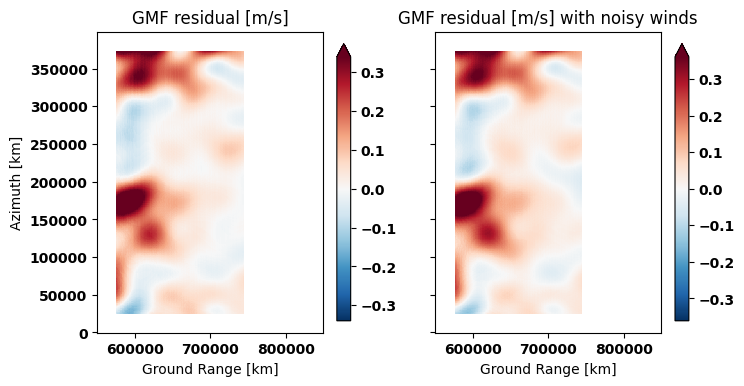

In [11]:
fig, axes = plt.subplots(ncols=2, nrows=1, sharex=True, sharey=True, figsize = (8, 6))

simulation['wave_dop_residual_velocity'].plot(ax = axes[0], robust = True, cbar_kwargs={"label": "", "shrink" : 0.6})
simulation['wave_dop_residual_velocity_noisy'].plot(ax = axes[1], robust = True, cbar_kwargs={"label": "", "shrink" : 0.6})

_ = [ax.set_aspect('equal') for ax in axes.flatten()]

_ = axes[0].set_title("GMF residual [m/s]")
_ = axes[1].set_title("GMF residual [m/s] with noisy winds")

axes[1].set_xlabel("Ground Range [km]")
axes[0].set_xlabel("Ground Range [km]")

axes[1].set_ylabel("")
axes[0].set_ylabel("Azimuth [km]")

In [12]:
print("Doppler RMSE of noise-FREE residual:", func_rmse(simulation['wave_dop_residual_velocity']))
print("Doppler RMSE of noisy residual:", func_rmse(simulation['wave_dop_residual_velocity_noisy']))

Doppler RMSE of noise-FREE residual: 0.114
Doppler RMSE of noisy residual: 0.124
